## 1) Mount path

In [1]:
from google.colab import drive

# Mount your Google Drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


## 2) Load PREPROCESSED SPLITTED TEST (80:20) images

In [2]:
### Training data (80%)
split_80_adenoc_train = '/content/drive/My Drive/PYTHON/ML_image_process/binary_classification_adenocarcinoma/split_data_TRAIN/80_train/adenocarcinoma'
split_80_normal_train = '/content/drive/My Drive/PYTHON/ML_image_process/binary_classification_adenocarcinoma/split_data_TRAIN/80_train/normal'

## validated data from training data (20%)
split_20_adenoc_val = '/content/drive/My Drive/PYTHON/ML_image_process/binary_classification_adenocarcinoma/split_data_TRAIN/20_val/adenocarcinoma'
split_20_normal_val = '/content/drive/My Drive/PYTHON/ML_image_process/binary_classification_adenocarcinoma/split_data_TRAIN/20_val/normal'

# External validation data (100%)
prep_adenocarcinoma_test = '/content/drive/My Drive/PYTHON/ML_image_process/binary_classification_adenocarcinoma/preprocessed/prep_adenocarcinoma_test'
prep_normal_test = '/content/drive/My Drive/PYTHON/ML_image_process/binary_classification_adenocarcinoma/preprocessed/prep_normal_test'

## 3) Import libraries

In [8]:
import os
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import VGG16
from tensorflow.keras import models, layers
from tensorflow.keras.optimizers import Adam

## 6) Rescale validation and Test Data

In [12]:
# Rescale for validation data (no augmentation)
val_datagen = ImageDataGenerator(rescale=1./255)

# Rescale for test data (no augmentation)
test_datagen = ImageDataGenerator(rescale=1./255)


## 7) Load Training Data (80%)

In [25]:
# Loading the training data (80% adenocarcinoma and normal)

#MUST USE PARENT DIRECTORY for "flow_from_directory"
train_data = train_datagen.flow_from_directory(
    '/content/drive/My Drive/PYTHON/ML_image_process/binary_classification_adenocarcinoma/split_data_TRAIN/80_train/',
    target_size=(img_height, img_width),
    batch_size=32,
    class_mode='binary',  # Binary classification (Adenocarcinoma vs Normal)
    shuffle=True
)


Found 749 images belonging to 2 classes.


## 8)Load Validation data (20%)

In [26]:
# Loading the validation data (20% adenocarcinoma and normal)
val_data = val_datagen.flow_from_directory(
    '/content/drive/My Drive/PYTHON/ML_image_process/binary_classification_adenocarcinoma/split_data_TRAIN/20_val/',
    target_size=(img_height, img_width),
    batch_size=32,
    class_mode='binary',  # Binary classification (Adenocarcinoma vs Normal)
    shuffle=True
)


Found 372 images belonging to 2 classes.


## 9) Load external/ separate test data (100%)

In [27]:
# Loading the external test dataset
test_data = test_datagen.flow_from_directory(
    '/content/drive/My Drive/PYTHON/ML_image_process/binary_classification_adenocarcinoma/preprocessed/PREP_DATA_FOR_MODEL',
    target_size=(img_height, img_width),
    batch_size=32,
    class_mode='binary',
    shuffle=False  # No shuffling for test data
)


Found 113 images belonging to 2 classes.


## 10) Building CNN Model


##Define Image Parameters

In [29]:
img_height = 224  # Adjust based on your dataset
img_width = 224
batch_size = 32


## create data generator

In [30]:
# Data augmentation for training
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True,
    zoom_range=0.2
)

val_datagen = ImageDataGenerator(rescale=1./255)

test_datagen = ImageDataGenerator(rescale=1./255)


## Load data

In [31]:
# Training Data (80%)
train_data = train_datagen.flow_from_directory(
    '/content/drive/My Drive/PYTHON/ML_image_process/binary_classification_adenocarcinoma/split_data_TRAIN/80_train',
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='binary',
    shuffle=True
)

# Validation Data (20%)
val_data = val_datagen.flow_from_directory(
    '/content/drive/My Drive/PYTHON/ML_image_process/binary_classification_adenocarcinoma/split_data_TRAIN/20_val',
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='binary',
    shuffle=True
)

# External Test Data (100%)
test_data = test_datagen.flow_from_directory(
    '/content/drive/My Drive/PYTHON/ML_image_process/binary_classification_adenocarcinoma/preprocessed/PREP_DATA_FOR_MODEL',
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='binary',
    shuffle=False
)


Found 749 images belonging to 2 classes.
Found 372 images belonging to 2 classes.
Found 113 images belonging to 2 classes.


## Build CNN model

In [33]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout


In [36]:
model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(img_height, img_width, 3)),
    MaxPooling2D(pool_size=(2,2)),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(pool_size=(2,2)),

    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(pool_size=(2,2)),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')  # Binary classification (Adenocarcinoma vs Normal)
])



## compile model

In [37]:
model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])


## 11) Train the model

In [39]:
history = model.fit(
    train_data,  # Make sure this is the combined train dataset (adenocarcinoma + normal)
    validation_data=val_data,  # Make sure this is the combined validation dataset
    epochs=10,  # Adjust epochs based on your dataset
    batch_size=32
)



Epoch 1/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 115s 5s/step - accuracy: 0.8486 - loss: 0.5180 - val_accuracy: 0.9220 - val_loss: 0.2734
Epoch 2/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 114s 5s/step - accuracy: 0.9321 - loss: 0.2646 - val_accuracy: 0.9220 - val_loss: 0.2638
Epoch 3/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 110s 5s/step - accuracy: 0.9364 - loss: 0.2483 - val_accuracy: 0.9220 - val_loss: 0.3581
Epoch 4/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 143s 6s/step - accuracy: 0.9243 - loss: 0.3069 - val_accuracy: 0.9220 - val_loss: 0.2656
Epoch 5/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 184s 5s/step - accuracy: 0.9218 - loss: 0.2787 - val_accuracy: 0.9220 - val_loss: 0.2674
Epoch 6/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 112s 5s/step - accuracy: 0.9196 - loss: 0.2886 - val_accuracy: 0.9220 - val_loss: 0.3069
Epoch 7/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 146s 5s/step - accuracy: 0.9085 - loss: 0.2900 - val_accuracy: 0.9220 - val_loss: 0.2572
Epoch 8/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 108s 5s/step - accuracy: 0.9281 - loss: 0.2454 - val_accuracy: 0.9220 - v

## 12) Evaluate the model on Test data

In [40]:
test_loss, test_accuracy = model.evaluate(test_data)
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")


4/4 ━━━━━━━━━━━━━━━━━━━━ 17s 5s/step - accuracy: 0.9342 - loss: 0.2989
Test Accuracy: 84.07%


## To check accuracy of model

After training, check the accuracy and loss for training, validation, and test data.

🔹 Good model:

Training accuracy ≈ Validation accuracy

Low training and validation loss

High test accuracy (ideally above 85-90%)

🔹 Bad model (overfitting or underfitting):

Training accuracy is very high (e.g., 98%) but validation accuracy is low (e.g., 60%) → Overfitting

Both training and validation accuracy are low → Model is underfitting

In [41]:
test_loss, test_accuracy = model.evaluate(test_data)
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")
print(f"Test Loss: {test_loss:.4f}")


4/4 ━━━━━━━━━━━━━━━━━━━━ 4s 797ms/step - accuracy: 0.9342 - loss: 0.2989
Test Accuracy: 84.07%
Test Loss: 0.5262


##Plot accuracy and loss curves

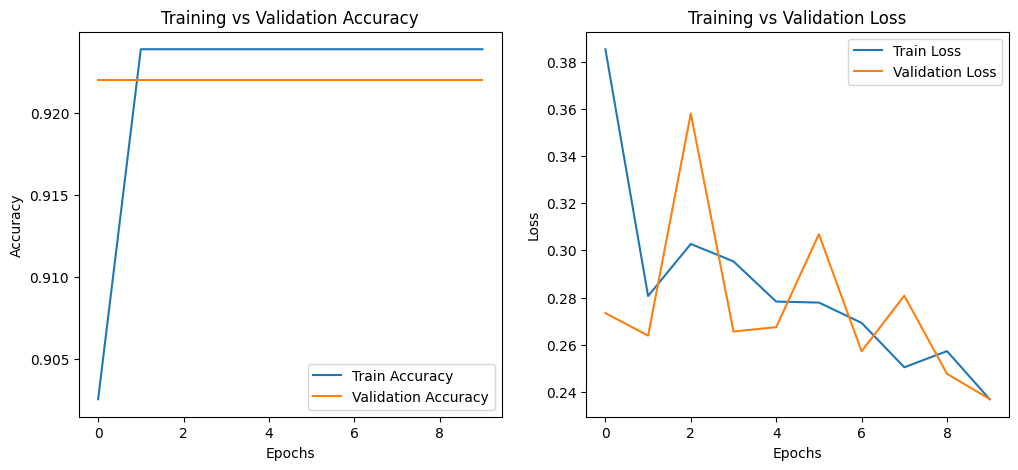

In [42]:
import matplotlib.pyplot as plt

# Plot accuracy
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Training vs Validation Accuracy')

# Plot loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.title('Training vs Validation Loss')

plt.show()


##Check confusion matrix & classification report

In [43]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

# Get true labels and predicted labels
true_labels = test_data.classes
predictions = model.predict(test_data)
predicted_labels = (predictions > 0.5).astype(int).flatten()

# Confusion matrix
print("Confusion Matrix:")
print(confusion_matrix(true_labels, predicted_labels))

# Classification report
print("Classification Report:")
print(classification_report(true_labels, predicted_labels, target_names=['Normal', 'Adenocarcinoma']))


4/4 ━━━━━━━━━━━━━━━━━━━━ 4s 837ms/step
Confusion Matrix:
[[95  0]
 [18  0]]
Classification Report:
                precision    recall  f1-score   support

        Normal       0.84      1.00      0.91        95
Adenocarcinoma       0.00      0.00      0.00        18

      accuracy                           0.84       113
     macro avg       0.42      0.50      0.46       113
  weighted avg       0.71      0.84      0.77       113



/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


##ROC curve & AUC score

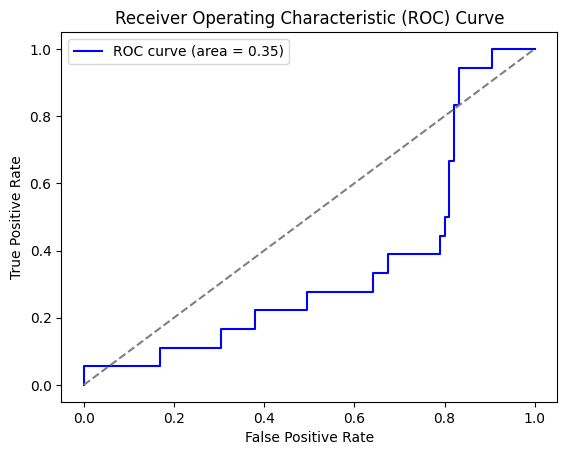

In [44]:
from sklearn.metrics import roc_curve, auc

fpr, tpr, _ = roc_curve(true_labels, predictions)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, color='blue', label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend()
plt.show()


###If training & validation accuracy are high AND test accuracy is high → Model is good.
### If test accuracy is much lower than training → Overfitting. Try dropout, data augmentation, or reducing complexity.
### If training accuracy is low → Model is underfitting. Try more layers, more training, or different hyperparameters.
###If confusion matrix and ROC curve show poor performance → Model needs improvement.



## 13) Save the model

In [45]:
model.save("cnn_model_adenocarcinoma.h5")



## Re-load the model

In [ ]:
from tensorflow.keras.models import load_model
model = load_model("cnn_model_adenocarcinoma.h5")
